# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import joblib
import os

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [40]:
df = pd.read_csv('../dataset-stroke-data.csv')

print(f"Shape dataset  : {df.shape}")
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print("\nContoh data (5 baris pertama):")
df.head()

Shape dataset  : (5110, 12)
Jumlah baris   : 5110
Jumlah kolom   : 12

Contoh data (5 baris pertama):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### a. Tipe data setiap kolom

In [41]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

### b. Statistik deskriptif

In [42]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### a. Cek Missing Values

In [43]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}) \
  .query('`Missing Count` > 0')

,Missing Count,Missing (%)
bmi,201,3.93


### b. Cek Duplikat

In [44]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


### c. Distribusi Target (stroke)

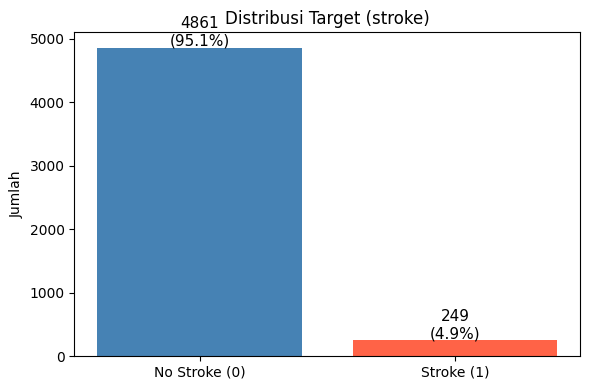

In [45]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['stroke'].value_counts()
ax.bar(['No Stroke (0)', 'Stroke (1)'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribusi Target (stroke)')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=100)
plt.show()
# Catatan: dataset sangat imbalanced (~95% no stroke, ~5% stroke)

### d. Distribusi Fitur Numerik

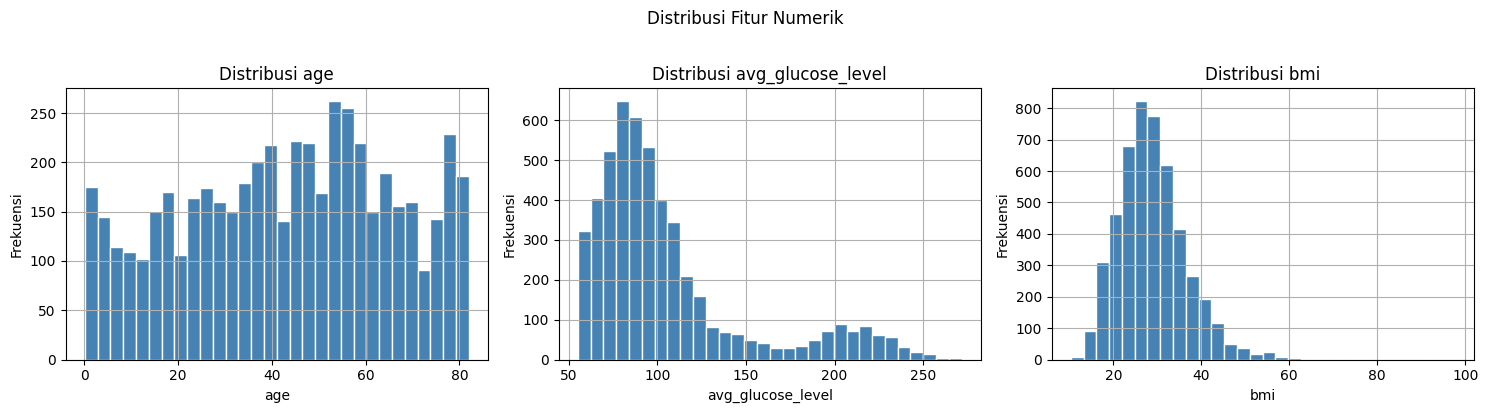

In [46]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df[col].dropna().hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
plt.suptitle('Distribusi Fitur Numerik', y=1.02)
plt.tight_layout()
plt.savefig('eda_numerical_distribution.png', dpi=100)
plt.show()

### e. Distribusi Fitur Kategorikal

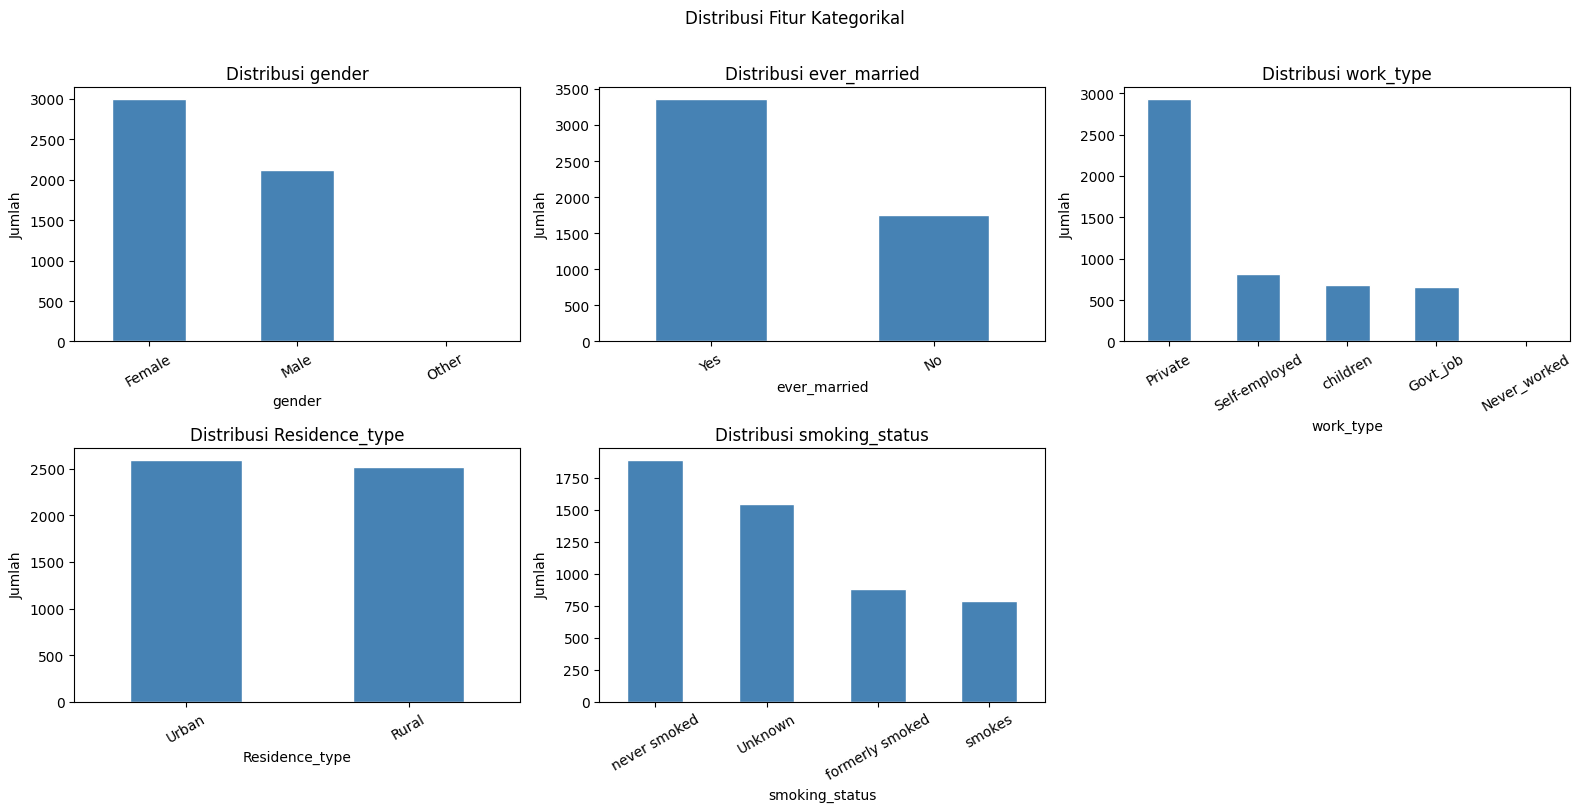

In [47]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i],
                                color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal', y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', dpi=100)
plt.show()

### f. Fitur Numerik vs Target (Boxplot)

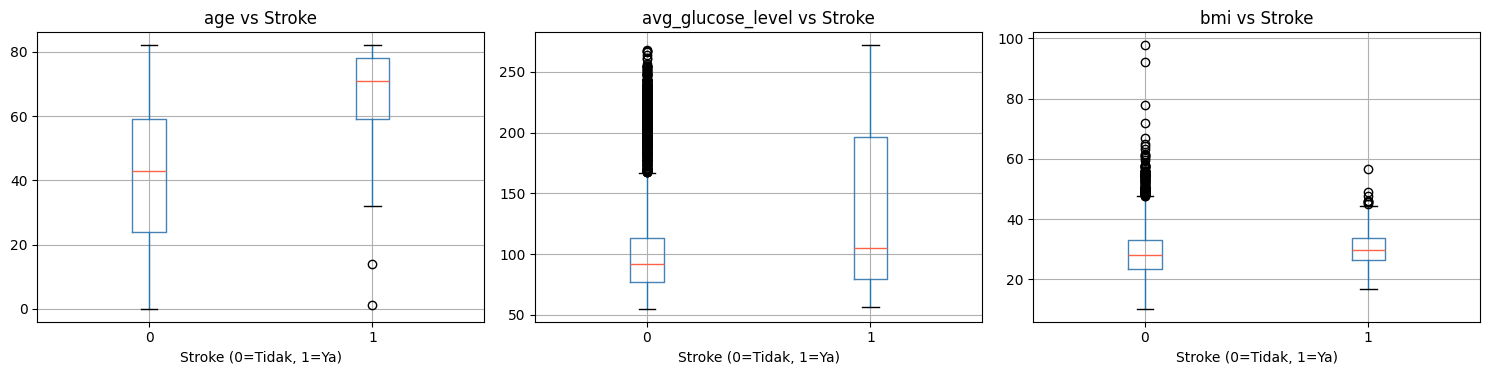

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='stroke', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato'))
    ax.set_title(f'{col} vs Stroke')
    ax.set_xlabel('Stroke (0=Tidak, 1=Ya)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_boxplot_vs_target.png', dpi=100)
plt.show()

### g. Correlation Heatmap

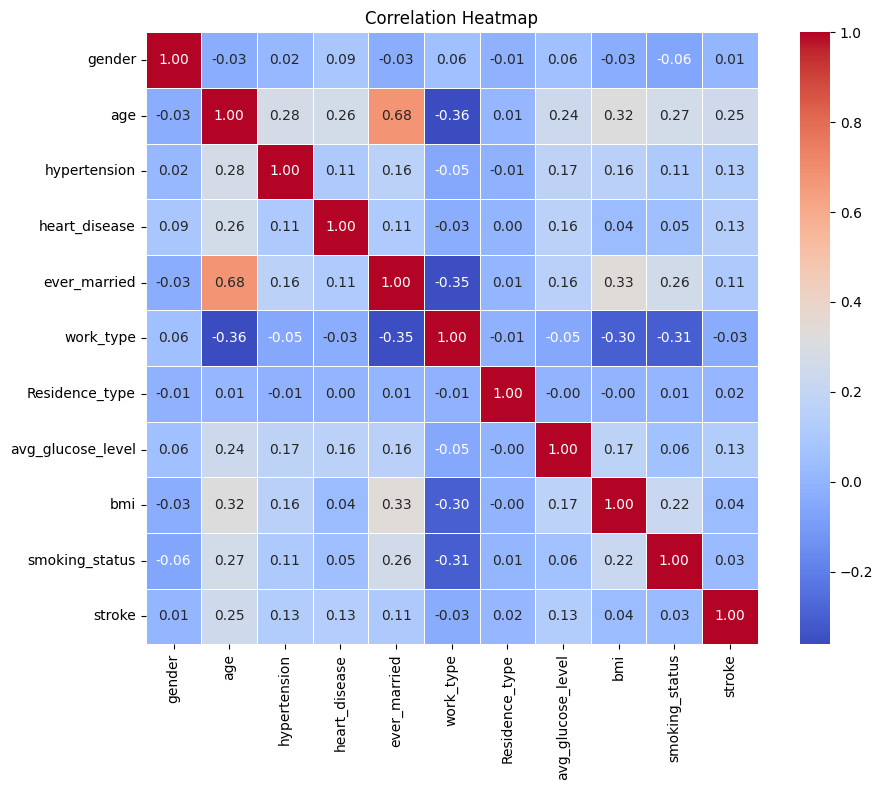

In [49]:
df_temp = df.drop(columns=['id'], errors='ignore').copy()
for col in df_temp.select_dtypes('object').columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col].astype(str))
df_temp['bmi'] = df_temp['bmi'].fillna(df_temp['bmi'].median())

plt.figure(figsize=(10, 8))
sns.heatmap(df_temp.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=100)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [50]:
df_clean = df.copy()

### a. Drop Kolom Tidak Relevan

In [51]:
df_clean = df_clean.drop(columns=['id'], errors='ignore')
print(f"Shape setelah drop 'id': {df_clean.shape}")

Shape setelah drop 'id': (5110, 11)


### b. Hapus Duplikat

In [52]:
df_clean = df_clean.drop_duplicates()
print(f"Shape setelah drop duplikat: {df_clean.shape}")

Shape setelah drop duplikat: (5110, 11)


### c. Handle Missing Values

In [53]:
TARGET_COL    = 'stroke'
numerical_cols   = [c for c in df_clean.select_dtypes('number').columns if c != TARGET_COL]
categorical_cols = df_clean.select_dtypes('object').columns.tolist()

imputer = SimpleImputer(strategy='median')
df_clean[numerical_cols] = imputer.fit_transform(df_clean[numerical_cols])
print(f"Missing setelah imputation: {df_clean.isnull().sum().sum()}")

Missing setelah imputation: 0


### d. Encoding Kolom Kategorikal

In [54]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
print(f"Kolom setelah encoding: {df_clean.dtypes}")

Kolom setelah encoding: gender                 int64
age                  float64
hypertension         float64
heart_disease        float64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
dtype: object


### e. Scaling Fitur Numerik

In [55]:
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numerical_cols)],
    remainder='drop'
)
data_scaled = preprocessor.fit_transform(df_clean[numerical_cols])
df_clean[numerical_cols] = data_scaled
print("Scaling selesai.")
df_clean.describe()

Scaling selesai.


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5.110000e+03,5.110000e+03,5.110000e+03,5110.000000,5110.000000,5110.000000,5.110000e+03,5.110000e+03,5110.000000,5110.000000
mean,0.414286,5.005781e-17,-4.727682e-17,5.561978e-18,0.656164,2.167710,0.508023,1.001156e-16,-4.449583e-17,1.376908,0.048728
std,0.493044,1.000098e+00,1.000098e+00,1.000098e+00,0.475034,1.090293,0.499985,1.000098e+00,1.000098e+00,1.071534,0.215320
min,0.000000,-1.908261e+00,-3.286019e-01,-2.389468e-01,0.000000,0.000000,0.000000,-1.126958e+00,-2.411027e+00,0.000000,0.000000
25%,0.000000,-8.061152e-01,-3.286019e-01,-2.389468e-01,0.000000,2.000000,0.000000,-6.383223e-01,-6.575089e-01,0.000000,0.000000
50%,0.000000,7.843218e-02,-3.286019e-01,-2.389468e-01,1.000000,2.000000,1.000000,-3.149945e-01,-9.898092e-02,2.000000,0.000000
75%,1.000000,7.860701e-01,-3.286019e-01,-2.389468e-01,1.000000,3.000000,1.000000,1.754080e-01,5.115031e-01,2.000000,0.000000
max,2.000000,1.714845e+00,3.043196e+00,4.185032e+00,1.000000,4.000000,1.000000,3.657145e+00,8.928390e+00,3.000000,1.000000


### f. Simpan Hasil Preprocessing

In [56]:
output_folder = 'stroke_preprocessing'
os.makedirs(output_folder, exist_ok=True)

# Simpan CSV
output_file = os.path.join(output_folder, 'stroke_preprocessed.csv')
df_clean.to_csv(output_file, index=False)
print(f"Dataset preprocessed disimpan: {output_file}")
print(f"Shape akhir: {df_clean.shape}")

# Simpan artifacts (.pkl) — konsisten dengan automate_Alief_Athallah.py
joblib.dump(imputer,        os.path.join(output_folder, 'imputer.pkl'))
joblib.dump(label_encoders, os.path.join(output_folder, 'label_encoders.pkl'))
joblib.dump(preprocessor,   os.path.join(output_folder, 'preprocessor.pkl'))
print("Artifacts (.pkl) berhasil disimpan.")

Dataset preprocessed disimpan: stroke_preprocessing\stroke_preprocessed.csv
Shape akhir: (5110, 11)
Artifacts (.pkl) berhasil disimpan.
